/Users/ajay.amrite/Documents/AI Course/Capstone/Black-Box functions/models/SurrogateNN.py:117: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


Epoch 1/500, Train Loss: 0.904184, Val Loss: 1.154079
Epoch 50/500, Train Loss: 0.166680, Val Loss: 0.515643
Epoch 100/500, Train Loss: 0.024635, Val Loss: 0.111588
Epoch 150/500, Train Loss: 0.001729, Val Loss: 0.042602
Epoch 200/500, Train Loss: 0.000076, Val Loss: 0.033013
Epoch 250/500, Train Loss: 0.000007, Val Loss: 0.031962
Epoch 300/500, Train Loss: 0.000001, Val Loss: 0.031868
Early stopping at epoch 341, best val_loss=0.031873


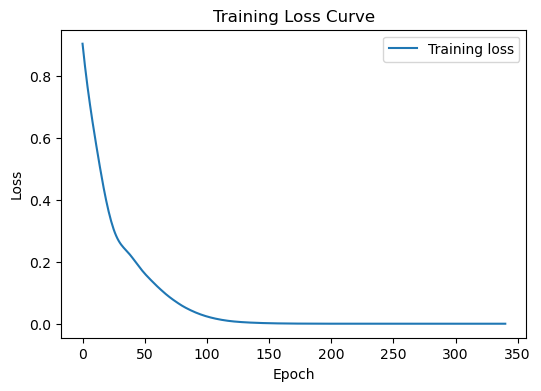

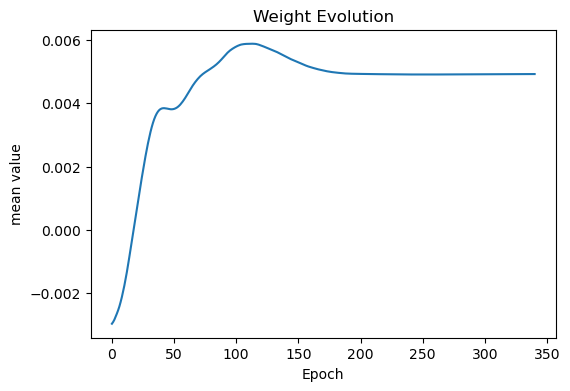

Using 4 dimensions.
Points before downsampling: 100000000
Points after downsampling: 100000000
Final grid shape: (100000000, 4)
Filtered 12804899 candidates near decision boundary (|margin| < 0.2)
Excluded 87195101 candidates from consideration
Final grid shape: (12804899, 4)
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([ 0.57548986, -0.01502845, -0.02457149, -0.01848344]), 'score': 0.041466183068919006, 'dim': 4, 'predicted_y': 0.5859011}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([ 0.57548986, -0.01502845, -0.02457149, -0.01848344]), 'score': 0.029257609001400654, 'dim': 4, 'predicted_y': 0.5859011}
{'method': 'PI', 'xi': 0.3, 'kappa': None, 'x': array([ 0.58708377, -0.04876609, -0.03565221, -0.01848344]), 'score': 0.012699047270317822, 'dim': 4, 'predicted_y': 0.5521152}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([ 0.58708377, -0.04876609, -0.03565221, -0.01848344]), 'score': 0.00970161237393622, 'dim': 4, 'predi

In [1]:
# flows/function1_flow.py

import sys, os
try:
    # Works when running as a normal Python script
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Fallback for Jupyter/IPython where __file__ is not defined
    project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

from data.BaseDataHandler import BaseDataHandler
from optimisation.BayesOptUtils import BayesOptUtils
from plotting.PlotUtils import PlotUtils
from Function4DataHandler import Function4DataHandler  # same folder
from models.SurrogateNN import SurrogateTrainer

# --- Data ---
dh = Function4DataHandler()
dh.add_weekly_updates()
df_sorted = dh.build_dataframe()
X, y = dh.inputs, dh.outputs

# --- Utilities ---
utils = BayesOptUtils()
plotter = PlotUtils()
trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)

# --- Hyperparameters supplied here ---
xi_values = [0.01, 0.1, 0.3]
kappa_values = [1.0, 2.0, 3.0]
grid_sizes = [100]
methods = ['PI', 'EI', 'UCB']
apply_scaling = True
filter_mode = 'median'

# --- Run flow ---
results = utils.run_flow(
    trainer, X, y,
    xi_values=xi_values,
    kappa_values=kappa_values,
    grid_sizes=grid_sizes,
    methods=methods,
    apply_scaling=apply_scaling,
    filter_mode=filter_mode
)



=== Results for grid_size=100 ===


/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


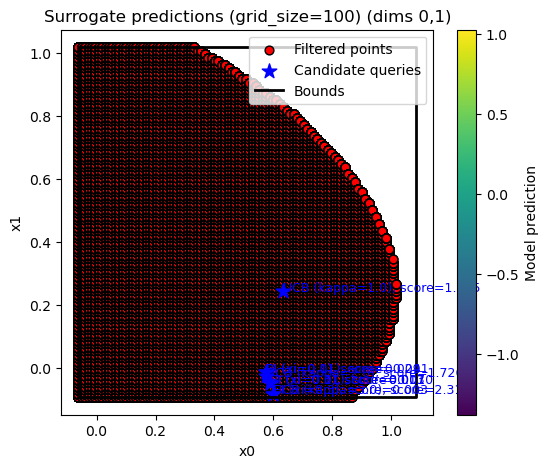

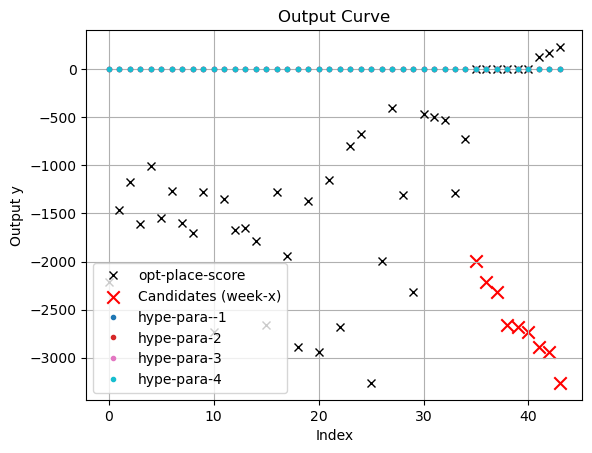

Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([ 0.59867768, -0.08250372, -0.03565221, -0.01848344]), 'score': 2.3186888082689827, 'dim': 4, 'predicted_y': 0.52986765}


In [2]:
# --- Loop over results and plot ---
for grid_size, (X_grid_filtered, mean, bounds, best, query_results, acq_maps) in results.items():
    print(f"\n=== Results for grid_size={grid_size} ===")

    # Extract candidates and labels
    candidates, labels = plotter.extract_candidates_and_labels(query_results, include_score=True)

    # Surrogate predictions plot
    plotter.plot_surrogate_generic(
        X_grid_filtered, mean,
        X_filtered=X_grid_filtered,
        bounds=bounds,
        candidates=candidates,
        candidate_labels=labels,
        title=f"Surrogate predictions (grid_size={grid_size})"
    )

    # Append candidates to BaseDataHandler and rebuild DataFrame
    cand_array, y_pred_array = dh.extract_candidate_arrays(query_results)
    dh.add_candidates(cand_array, y_pred_array)  # updates inputs/outputs/source_labels
    df_sorted = dh.build_dataframe()             # rebuild from updated arrays

    # Re-plot updated DataFrame
    plotter.plot_output_points(
        df_sorted,
        scale_factor=1.0,
        yield_scale_factor=100.0,
        source_marker='week-x',          # highlight all rows with source == 'week-x'
        source_color='red',
        source_marker_style='x'
    )
    # Print best candidate info
    print("Best candidate:", best)